In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import missingno as ms
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as pl

In [3]:
df = pd.read_excel("emdat-country-profiles_2026_06_06.xlsx")

df = df.drop(index=0).reset_index(drop=True)
df.head()

,Year,Country,ISO,Disaster Group,Disaster Subroup,Disaster Type,Disaster Subtype,Total Events,Total Affected,Total Deaths,"Total Damage (USD, original)","Total Damage (USD, adjusted)",CPI
0,2000,Afghanistan,AFG,Natural,Climatological,Drought,Drought,1,2580000,37,50000.0,93479,53.487737
1,2000,Algeria,DZA,Natural,Hydrological,Flood,Flash flood,1,100,28,NaN,NaN,53.487737
2,2000,Angola,AGO,Natural,Hydrological,Flood,Flood (General),3,9011,15,NaN,NaN,53.487737
3,2000,Angola,AGO,Natural,Hydrological,Flood,Riverine flood,1,70000,31,10000000.0,18695874,53.487737
4,2000,Angola,AGO,Natural,Hydrological,Mass movement (wet),Landslide (wet),1,NaN,13,NaN,NaN,53.487737


In [4]:
df.columns

Index(['Year', 'Country', 'ISO', 'Disaster Group', 'Disaster Subroup',
       'Disaster Type', 'Disaster Subtype', 'Total Events', 'Total Affected',
       'Total Deaths', 'Total Damage (USD, original)',
       'Total Damage (USD, adjusted)', 'CPI'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6507 entries, 0 to 6506
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Year                          6507 non-null   object 
 1   Country                       6507 non-null   str    
 2   ISO                           6507 non-null   str    
 3   Disaster Group                6507 non-null   str    
 4   Disaster Subroup              6507 non-null   str    
 5   Disaster Type                 6507 non-null   str    
 6   Disaster Subtype              6507 non-null   str    
 7   Total Events                  6507 non-null   object 
 8   Total Affected                5280 non-null   object 
 9   Total Deaths                  4648 non-null   object 
 10  Total Damage (USD, original)  2213 non-null   float64
 11  Total Damage (USD, adjusted)  2200 non-null   object 
 12  CPI                           6430 non-null   float64
dtypes: float64(2),

In [6]:
df.describe()

,"Total Damage (USD, original)",CPI
count,2.213000e+03,6430.000000
mean,1.753654e+09,72.690106
std,8.716576e+09,13.262874
min,2.000000e+03,53.487737
25%,2.050000e+07,62.617195
50%,1.400000e+08,71.315088
75%,8.400000e+08,80.390383
max,2.100000e+11,100.000000


In [7]:
cols = ['Total Events', 'Total Affected', 'Total Deaths', "Year"]

df[cols] = df[cols].apply(pd.to_numeric, errors='coerce').astype('Int64')
df["Total Damage (USD, adjusted)"] = df["Total Damage (USD, adjusted)"].apply(pd.to_numeric, 
                                                                              errors='coerce').astype('float')

# mehema damme null val handle karala nathi nisa thama ethakota corrupted vals nan replace wenawa
df.dtypes


Year                              Int64
Country                             str
ISO                                 str
Disaster Group                      str
Disaster Subroup                    str
Disaster Type                       str
Disaster Subtype                    str
Total Events                      Int64
Total Affected                    Int64
Total Deaths                      Int64
Total Damage (USD, original)    float64
Total Damage (USD, adjusted)    float64
CPI                             float64
dtype: object

In [8]:

missing = pd.DataFrame({
    "Count": df.isna().sum(),
    "Percentage": (df.isna().sum() / len(df)) * 100
})
missing

,Count,Percentage
Year,0,0.000000
Country,0,0.000000
ISO,0,0.000000
Disaster Group,0,0.000000
Disaster Subroup,0,0.000000
Disaster Type,0,0.000000
Disaster Subtype,0,0.000000
Total Events,0,0.000000
Total Affected,1227,18.856616
Total Deaths,1859,28.569233


<Axes: >

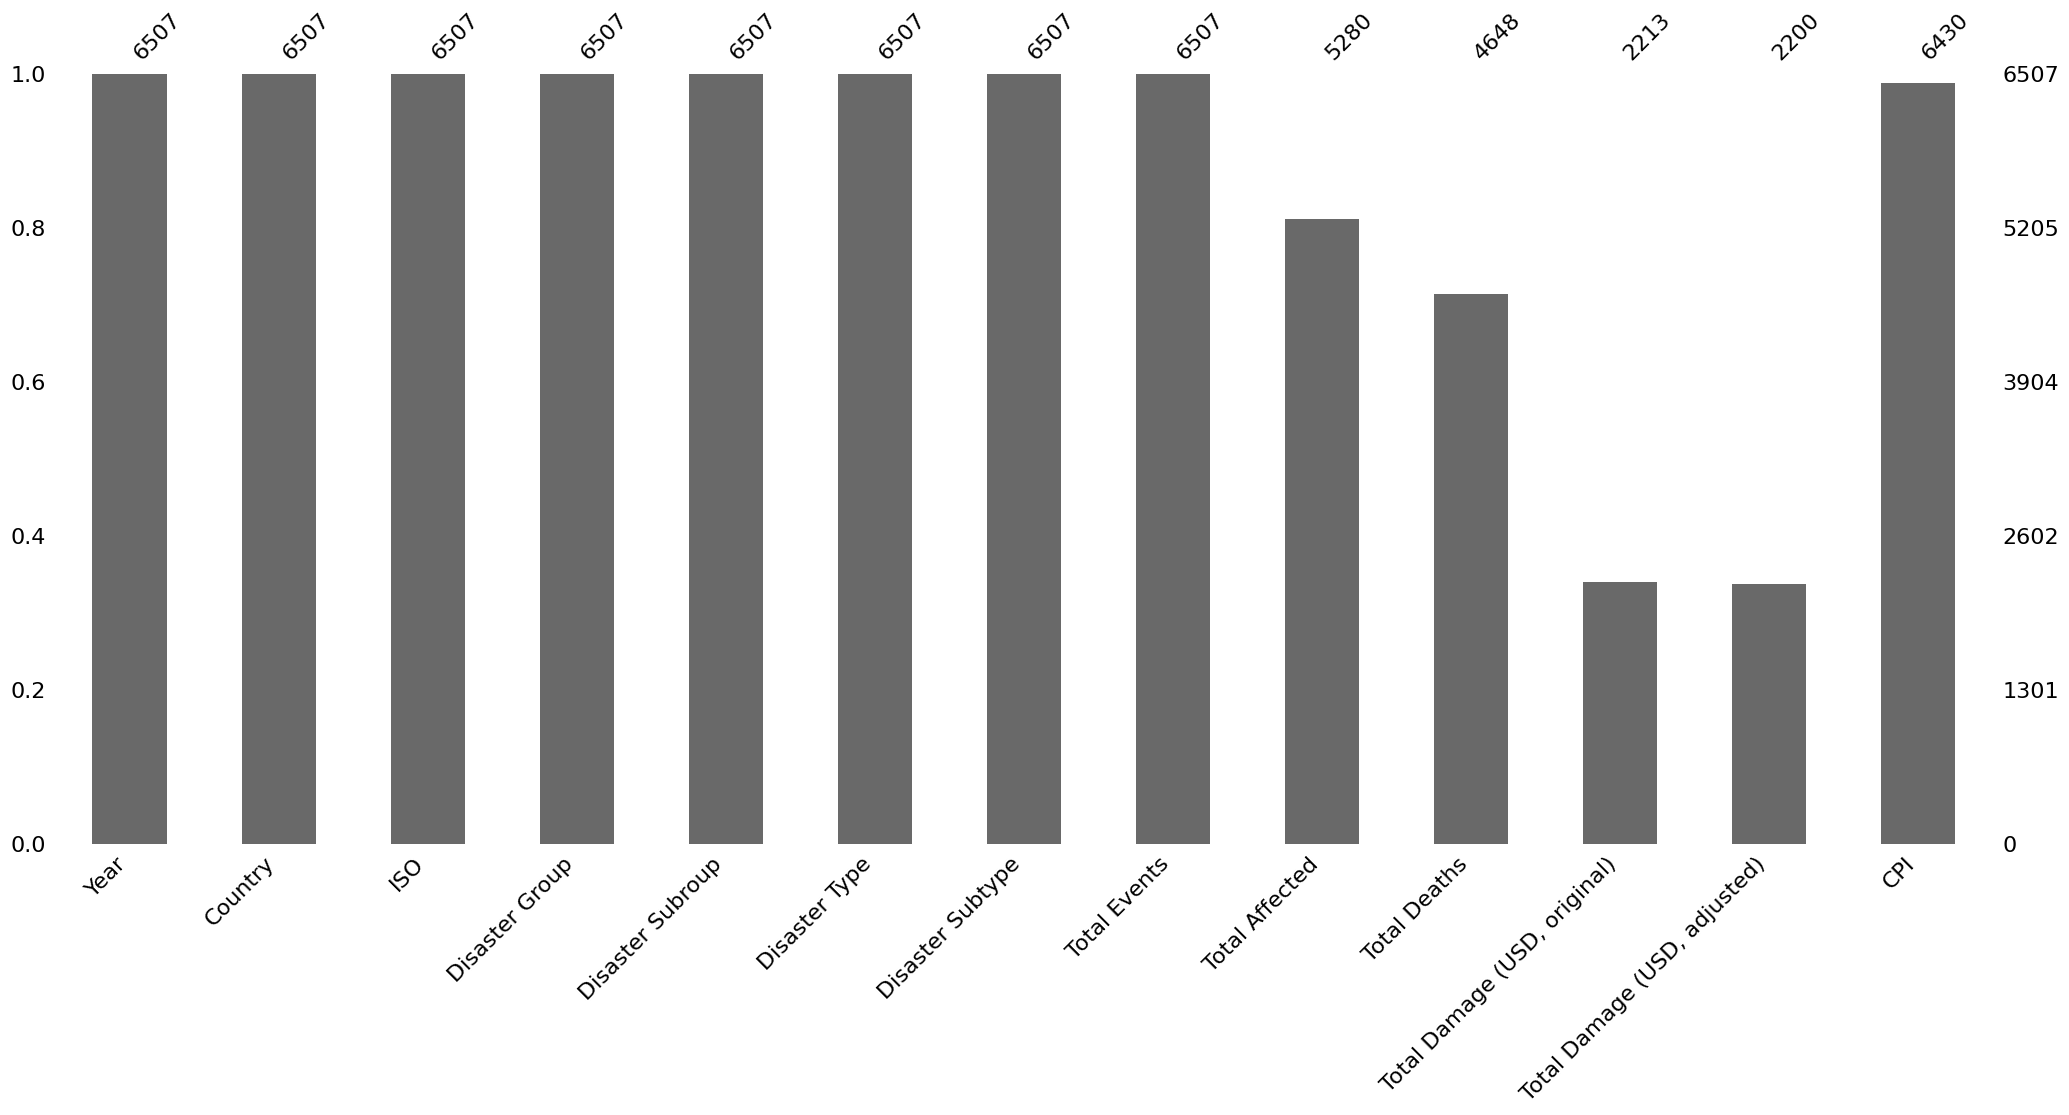

In [9]:
ms.bar(df)

In [10]:
# low-mod nan - meadian(safer than mean for skewed disaster data)
cols = ['Total Affected', 'Total Deaths']

df[cols] = df[cols].fillna(df[cols].median())

df['CPI'] = df['CPI'].fillna(df['CPI'].median())

# i mean this is fine kelinma remove karanne nathuwa bias eka prevent karanawa
# “missing = low damage” (which would be wrong)
df['damage_missing'] = df['Total Damage (USD, original)'].isna().astype(int)

df['Total Damage (USD, original)'] = df['Total Damage (USD, original)'].fillna(
    df['Total Damage (USD, original)'].median()
)

In [11]:
df.isna().sum()

Year                               0
Country                            0
ISO                                0
Disaster Group                     0
Disaster Subroup                   0
Disaster Type                      0
Disaster Subtype                   0
Total Events                       0
Total Affected                     0
Total Deaths                       0
Total Damage (USD, original)       0
Total Damage (USD, adjusted)    4307
CPI                                0
damage_missing                     0
dtype: int64

array([[<Axes: title={'center': 'Total Deaths'}>,
        <Axes: title={'center': 'Total Affected'}>],
       [<Axes: title={'center': 'Total Damage (USD, original)'}>,
        <Axes: >]], dtype=object)

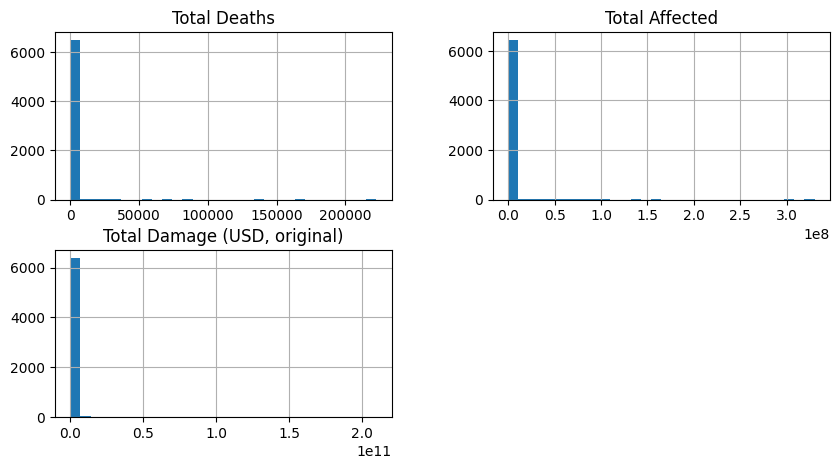

In [12]:
#Distribution of these
df[['Total Deaths','Total Affected','Total Damage (USD, original)']].hist(bins=30, 
                                                                          figsize=(10,5))

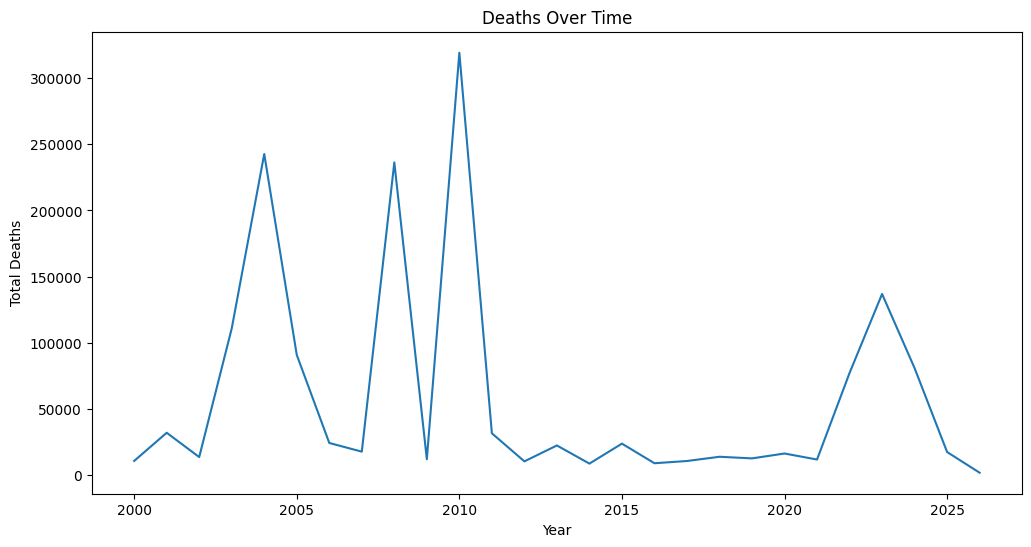

In [13]:
year_wise_impact = df.groupby('Year')['Total Deaths'].sum()

plt.figure(figsize=(12,6))
plt.plot(year_wise_impact.index, year_wise_impact.values)
plt.title('Deaths Over Time')
plt.xlabel('Year')
plt.ylabel('Total Deaths')
plt.show()

In [14]:
df.groupby('Disaster Type')['damage_missing'].mean().sort_values(ascending=False)

Disaster Type
Animal incident                1.000000
Infestation                    0.965517
Mass movement (dry)            0.928571
Extreme temperature            0.912879
Mass movement (wet)            0.864130
Volcanic activity              0.840708
Glacial lake outburst flood    0.714286
Drought                        0.706311
Flood                          0.671555
Wildfire                       0.611940
Storm                          0.539954
Earthquake                     0.498818
Impact                         0.000000
Name: damage_missing, dtype: float64

Economic damage reporting varies substantially by disaster type. Animal incidents, infestations, and extreme temperature events exhibit very high levels of missing damage data (>90%), whereas earthquakes, storms, and floods have comparatively better reporting. This indicates that damage missingness is systematic rather than random and should be accounted for during modeling.

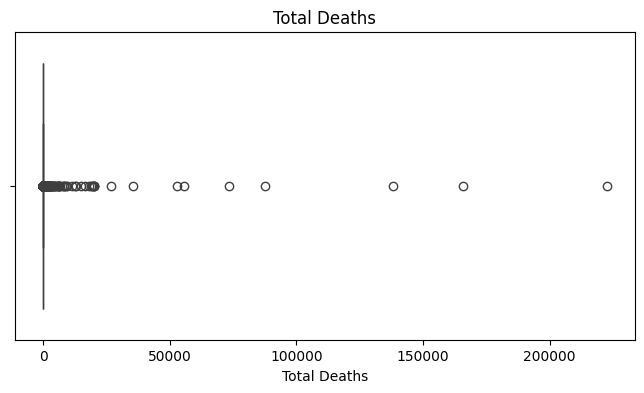

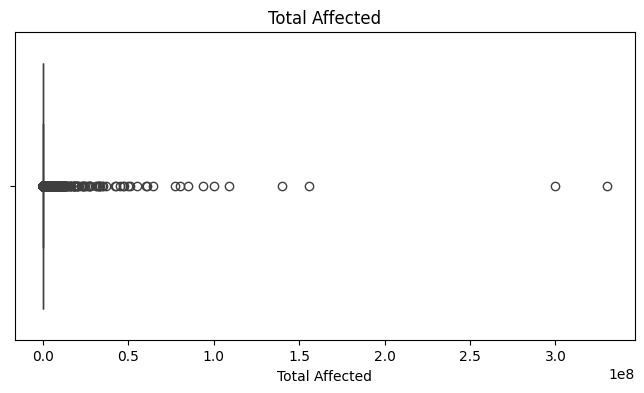

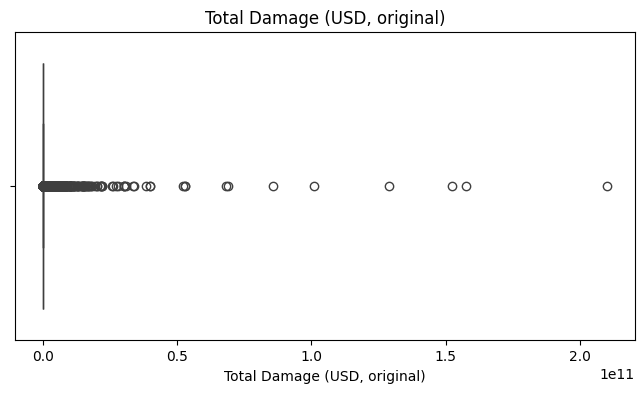

In [15]:
df[['Total Deaths',
    'Total Affected',
    'Total Damage (USD, original)']].describe(percentiles=[0.25,0.5,0.75,0.9,0.95,0.99])

for col in ['Total Deaths','Total Affected','Total Damage (USD, original)']:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

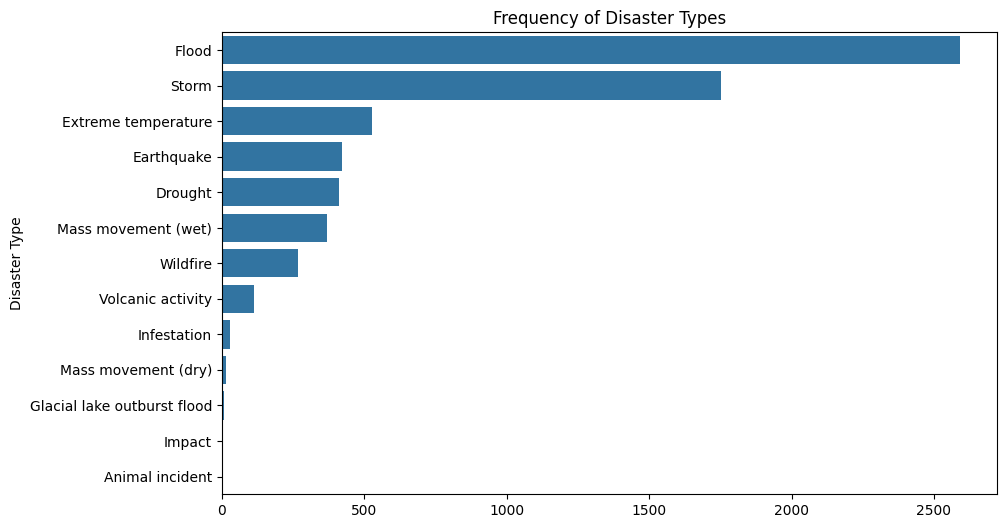

In [16]:
disaster_counts = df['Disaster Type'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(
    x=disaster_counts.values,
    y=disaster_counts.index
)
plt.title('Frequency of Disaster Types')
plt.show()

In [17]:
df['Country'].value_counts().head(20)
#this is not also balanced

Country
United States of America    263
China                       225
India                       181
Indonesia                   158
Philippines                 131
Japan                       109
Bangladesh                  107
Pakistan                    107
France                       98
Viet Nam                     96
Mexico                       92
Afghanistan                  90
Australia                    89
Italy                        82
Russian Federation           82
Brazil                       80
Peru                         79
Thailand                     79
Colombia                     78
Argentina                    71
Name: count, dtype: int64

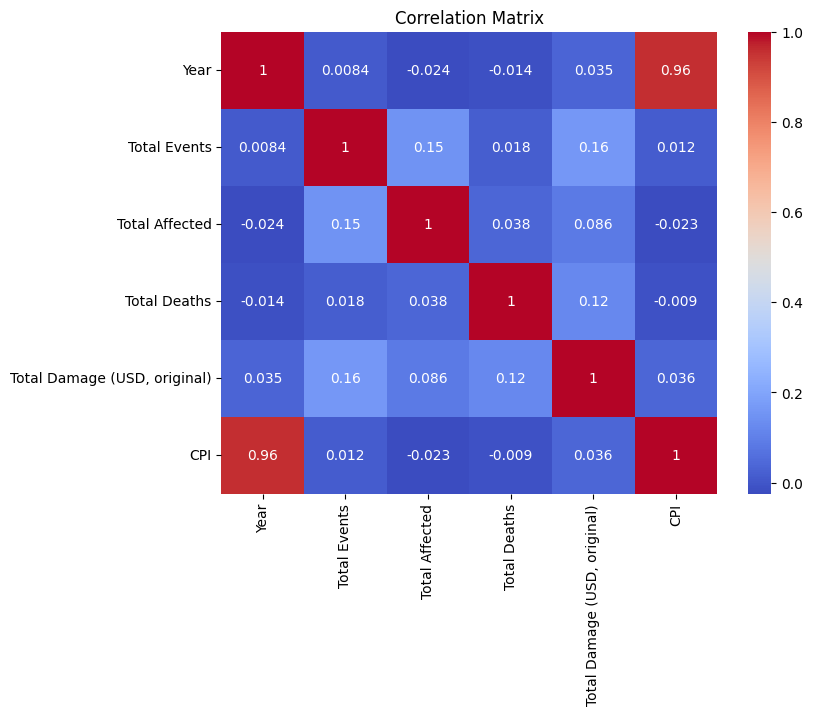

In [18]:
num_cols = [
    'Year',
    'Total Events',
    'Total Affected',
    'Total Deaths',
    'Total Damage (USD, original)',
    'CPI'
]

corr = df[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()
# corr

Correlation analysis revealed generally weak linear relationships between total deaths and other numerical variables. The strongest relationship observed was between Year and CPI (r = 0.956), reflecting inflation trends over time. Fatalities showed only weak correlations with total events, affected population, and economic damage, suggesting that disaster mortality is influenced more by contextual factors such as disaster type and geographic location than by simple numerical indicators alone.

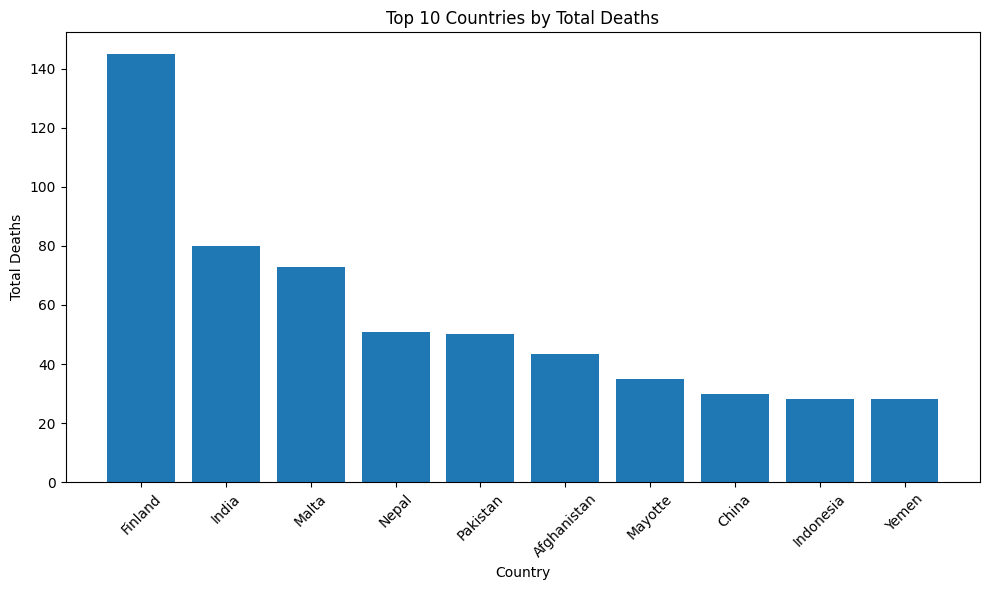

In [19]:
country_wise_impact = (
    df.groupby('Country')['Total Deaths']
      .median() 
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))
plt.bar(country_wise_impact.index, country_wise_impact.values)
plt.xlabel('Country')
plt.ylabel('Total Deaths')
plt.title('Top 10 Countries by Total Deaths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# country_wise_impact

Haiti, Indonesia, Myanmar, China, and India recorded the highest cumulative disaster-related deaths in the dataset. This suggests that disaster impacts are not evenly distributed across countries, and geographic location may play a significant role in determining disaster severity and mortality risk.

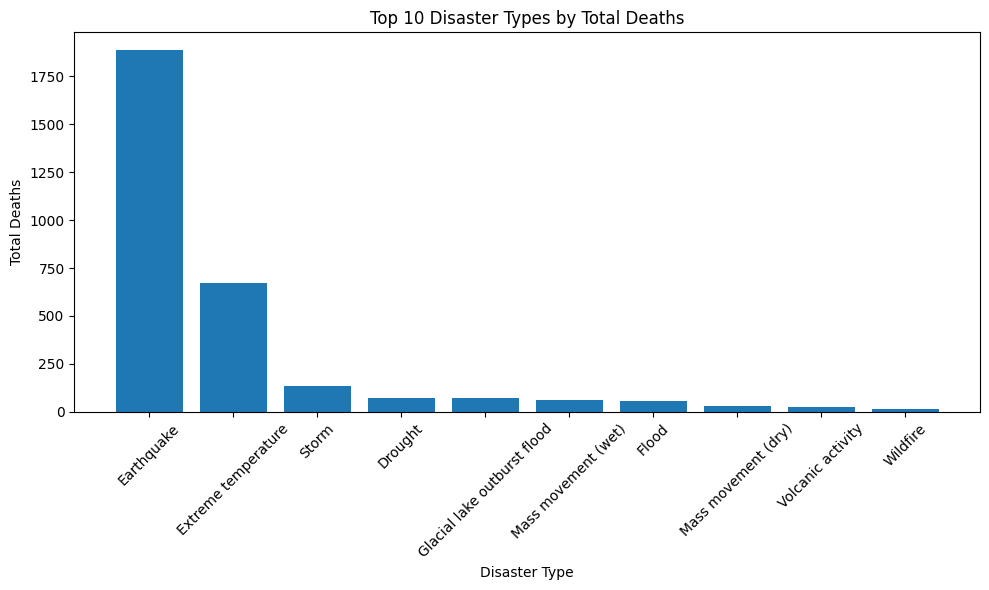

In [20]:
dis_type_wise_impact = (
    df.groupby('Disaster Type')['Total Deaths']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))
plt.bar(dis_type_wise_impact.index, dis_type_wise_impact.values)
plt.xlabel('Disaster Type')
plt.ylabel('Total Deaths')
plt.title('Top 10 Disaster Types by Total Deaths')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# dis_type_wise_impact

Earthquakes were found to be the deadliest disaster type, with a significantly higher average number of deaths compared to other disaster categories. Extreme temperature events ranked second, while storms, floods, and droughts showed comparatively lower average fatalities. This indicates that disaster type is likely to be an important predictor of mortality in the modeling phase.

For the corr and the above two:- 
The large variation in fatalities across countries and disaster types suggests that categorical features such as Country and Disaster Type may provide stronger predictive power than numerical variables alone when predicting disaster-related deaths.

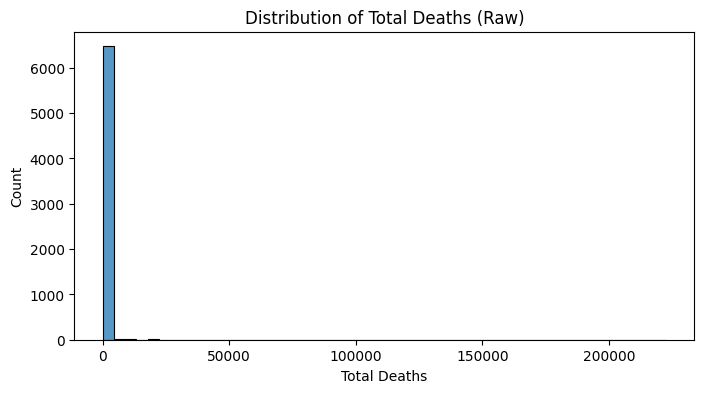

In [21]:
plt.figure(figsize=(8,4))
sns.histplot(df['Total Deaths'], bins=50)
plt.title("Distribution of Total Deaths (Raw)")
plt.show()

The distribution of Total Deaths is highly right-skewed, with most events resulting in low fatalities and a few extreme disasters causing very high death tolls. This creates a strong imbalance in the target variable, which can negatively affect model training.

To address this, a log transformation (log1p) is applied to reduce skewness and compress extreme values, resulting in a more balanced distribution suitable for regression modeling.

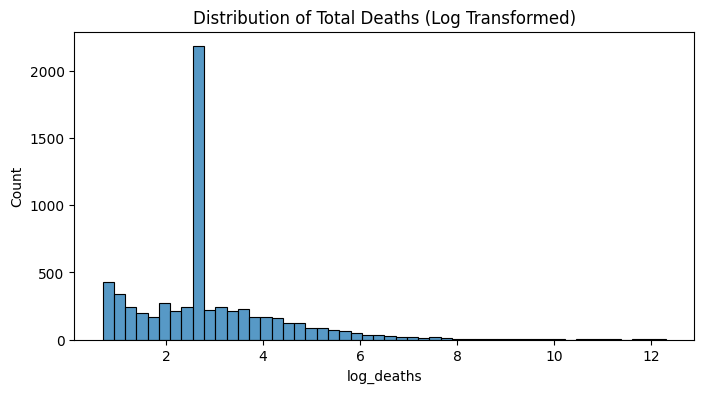

In [22]:
df_model = df.copy()

df_model = df_model[df_model['Total Deaths'].notna()]
df_model['log_deaths'] = np.log1p(df_model['Total Deaths'])

plt.figure(figsize=(8,4))
sns.histplot(df_model['log_deaths'], bins=50)
plt.title("Distribution of Total Deaths (Log Transformed)")
plt.show()

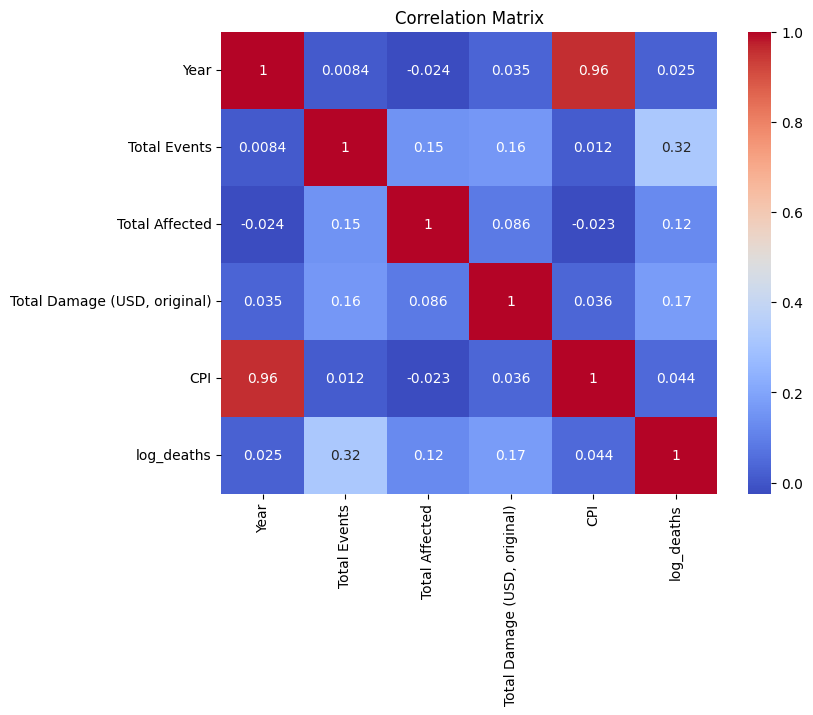

In [23]:
num_cols = [
    'Year',
    'Total Events',
    'Total Affected',
    'Total Damage (USD, original)',
    'CPI',
    'log_deaths'
]

corr = df_model[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Year and CPI are highly correlated (r ≈ 0.95), indicating overlapping temporal information
i did nothing hear for this cause u know tree models walata echchara case ekak na 

### Hypothesis Test 1: Disaster Type affects fatalities

Hypotheses:
* H₀: Mean deaths are the same across all disaster types
* H₁: At least one disaster type has different mean deaths

In [24]:
from scipy.stats import f_oneway

groups = [group["Total Deaths"].dropna()
          for name, group in df.groupby("Disaster Type")]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 6.279877135848772
p-value: 3.702655615536135e-11


* Since the p-value is extremely small (p < 0.05), we reject the null hypothesis.
* There is strong statistical evidence that mean fatalities differ significantly across disaster types. This confirms that disaster type is an important factor influencing mortality outcomes.

### Hypothesis Test 2: Country vs fatalities

Hypotheses:
* H₀: No difference in mean deaths between top countries and others
* H₁: There is a difference

In [35]:
from scipy.stats import ttest_ind

top_countries = df[df["Country"].isin(["Haiti", "Indonesia", "China"])]["Total Deaths"]
others = df[~df["Country"].isin(["Haiti", "Indonesia", "China"])]["Total Deaths"]

t_stat, p_value = ttest_ind(top_countries, others, nan_policy='omit')

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: 4.919744522044982
p-value: 8.878766094351643e-07


* Since the p-value is also extremely small (p < 0.05), we reject the null hypothesis.
* The results suggest that geographic location plays a statistically significant role in disaster-related fatalities, with certain countries experiencing systematically higher mortality rates than others.

Both statistical tests confirm that categorical variables such as Disaster Type and Country have a significant relationship with disaster-related fatalities. This supports earlier exploratory findings and reinforces the use of tree-based machine learning models, which are better suited to capture such complex, non-linear relationships.

In [25]:
features = [
    'Year',
    'Country',
    'Disaster Group',
    'Disaster Type',
    'Disaster Subtype',
    'Total Events',
    'CPI',
    'damage_missing'
]

In [26]:
X = df_model[features]
y = df_model['log_deaths']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [27]:
rfg_model = RandomForestRegressor(n_estimators=200, random_state=42)
rfg_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [28]:
rfg_pred = rfg_model.predict(X_test)

In [29]:
rfg_mae = mean_absolute_error(y_test, rfg_pred)
rfg_r2 = r2_score(y_test, rfg_pred)

print("MAE:", rfg_mae)
print("R2:", rfg_r2)

MAE: 0.8280742044155351
R2: 0.37210740350554916


In [30]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [31]:
xgb_y_pred = xgb_model.predict(X_test)

In [32]:
xgb_mae =  mean_absolute_error(y_test, xgb_y_pred)
xgb_r2 = r2_score(y_test, xgb_y_pred)

print("MAE:", xgb_mae)
print("R2:", xgb_r2)

MAE: 0.7965302239524946
R2: 0.43281349320939877


In [33]:
results = pd.DataFrame([
    {"Model": "XGBoost", "MAE": xgb_mae, "R2": xgb_r2},
    {"Model": "Random Forest", "MAE": rfg_mae, "R2": rfg_r2}
])
results

,Model,MAE,R2
0,XGBoost,0.796530,0.432813
1,Random Forest,0.828074,0.372107


The XGBoost model achieved the best performance with an R² score of 0.43 and MAE of 0.79, outperforming the Random Forest model, which achieved an R² of 0.37 and MAE of 0.82.

This indicates that XGBoost is better at capturing the non-linear relationships present in the dataset, which is expected due to its gradient boosting framework and stronger optimization capabilities compared to Random Forest.

However, the moderate R² values suggest that disaster-related fatalities are only partially explained by the available features. This is likely due to the inherent complexity of disaster impacts, where factors such as infrastructure quality, emergency response, population density, and preparedness—which are not included in the dataset—play a significant role.

Overall, while XGBoost provides improved predictive performance, the results highlight that predicting disaster fatalities is a challenging problem with substantial real-world variability.

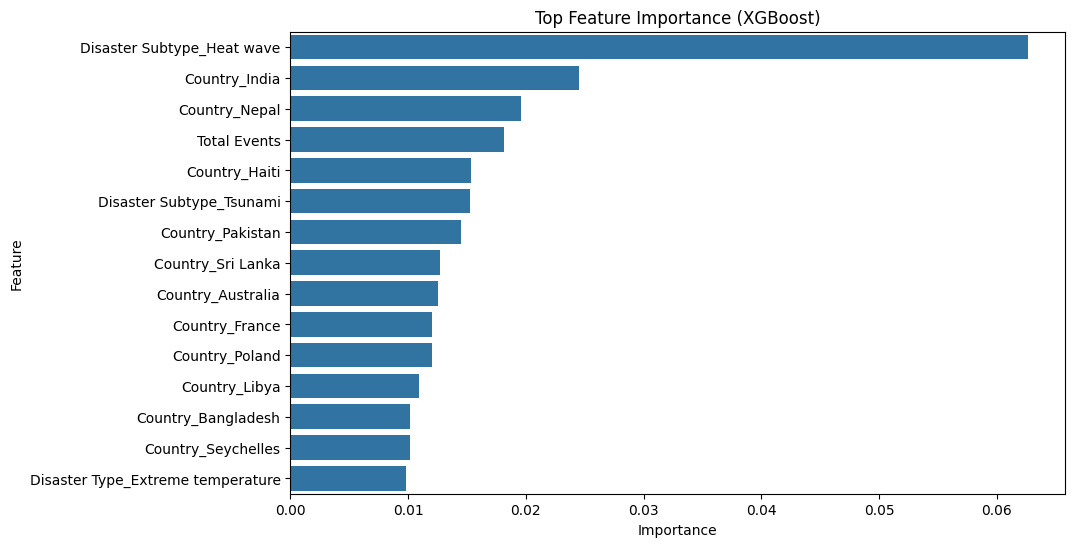

In [34]:
importances = xgb_model.feature_importances_

imp_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=imp_df.head(15), x="Importance", y="Feature")
plt.title("Top Feature Importance (XGBoost)")
plt.show()

Feature importance analysis from the XGBoost model shows that disaster subtype and country are the most influential predictors of disaster-related fatalities. In particular, extreme weather events such as heat waves and tsunamis contribute significantly to higher predicted deaths.

Country-level features also play a major role, indicating that geographic and socio-economic factors strongly influence disaster outcomes. This suggests that the model is capturing historical vulnerability patterns rather than purely physical disaster characteristics.

Overall, categorical features dominate numerical variables, reinforcing that disaster mortality is driven more by contextual and regional factors than by simple event counts or economic indicators.

conc --------

Tree-based models outperform linear regression because disaster mortality is driven by non-linear interactions and threshold effects between categorical and numerical variables, which linear models cannot capture effectively.

H0 (null hypothesis):

* Disaster-related fatalities can be adequately predicted using linear relationships between numerical variables only.

H1:

* Disaster-related fatalities are better explained by non-linear relationships between categorical and numerical features than by linear relationships alone.

* This study hypothesizes that disaster-related fatalities are primarily driven by complex non-linear interactions between categorical and numerical variables, rather than simple linear relationships. Specifically, it is expected that tree-based models such as Random Forest and XGBoost will outperform linear approaches due to their ability to capture interaction effects between disaster type, geographic location, and exposure-related variables.

* These are some other factors to support our hypothesis:

1. Correlation analysis result
* Weak correlation between fatalities and most numeric variables
* Strong correlation only between Year and CPI (not directly useful for prediction)

2. Categorical dominance
* Country and Disaster Type strongly affect fatalities
* Earthquakes, tsunamis, etc. show different fatality patterns

3. Model comparison
| Model         | Performance      |
| ------------- | ---------------- |
| Random Forest | lower R²         |
| XGBoost       | higher R² (0.43) |

4. Feature importance result
* Disaster subtype + country dominate predictions
* Numerical features less important